# Clean Dataset — Multi-Channel CNN for Cortical Layer Classification

**Goal.** Produce a clean, filtered working population of V1 excitatory neurons (best-only regime)
and train a multi-channel 1-D CNN classifier for cortical layer prediction.

## Filtering pipeline

| Step | Filter | Rationale |
|------|--------|-----------|
| 1 | `functional_data='best_only'` | One row per `nucleus_id`, highest-quality functional match. Avoids repeated-measure dependence and session-specific bias. |
| 2 | `brain_area='V1'` | V1 is the densest area; cleanest substrate for function-vs-identity question. |
| 3 | `cell_type='excitatory_neuron'` | Inhibitory and non-neuronal classes are out of scope. |
| 4 | `tuning='matched'` | Keep only neurons with reliable functional-to-structural coregistration — label cannot be trusted without coregistration. |

Expected population after all filters: **~8.9k neurons** (WORKFLOW.md §2.1).

## Model inputs (12 channels per trial)

| Channel | Source | Description |
|---------|--------|-------------|
| 0 | Neural | Z-scored calcium trace |
| 1–7 | Stimulus | Luminance, contrast, motion energy, gradient energy, edge fraction, centre-surround contrast, normalised contrast |
| 8–11 | Behaviour | Treadmill velocity, pupil x, pupil y, pupil size |

Workflow follows `tommy/FEATURES_ANALYSIS/CNN_multichannel.ipynb`.
Neurons are split train/test **by identity** (`nucleus_id`) — never by trial — to prevent leakage.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os
import warnings
import importlib
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Locate workspace root (directory that contains microns.h5) ────────────────
def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    p = Path.cwd()
    while p != p.parent:
        if (p / 'data' / '1718' / 'raw').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root (no microns.h5 found).')

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# reader.py lives one level up (tommy/)
TOMMY_DIR = Path(__file__).parent.parent if '__file__' in dir() else (Path.cwd() / '..').resolve()
if str(TOMMY_DIR) not in sys.path:
    sys.path.insert(0, str(TOMMY_DIR))

print(f'Workspace root : {ROOT}')
print(f'Tommy dir      : {TOMMY_DIR}')

Workspace root : c:\Users\tomma\Desktop\NEUROSCIENCE
Tommy dir      : C:\Users\tomma\Desktop\NEUROSCIENCE\neuroscience-project\tommy


## 1. Load structural metadata — `best_only` regime

Using `functional_data='best_only'` means `microns-datacleaner` returns **one row per `nucleus_id`**,
selecting the highest-quality functional match (highest `cc_abs`) when a neuron was recorded in
multiple scans. This is the **primary analysis regime** (WORKFLOW.md §3.1).

In [2]:
# ── Download / load structural data ──────────────────────────────────────────
cleaner = mic.MicronsDataCleaner(
    datadir=os.path.relpath(str(ROOT / 'data')),
    version=1718,
    download_policy='minimum',
)

# best_only: one row per nucleus_id, highest-quality functional match
units_best, _ = cleaner.process_nucleus_data(functional_data='best_only')

print(f'Rows returned by best_only: {len(units_best):,}')
print(f'Columns: {list(units_best.columns)}')

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 74307.23it/s]


Rows returned by best_only: 90,434
Columns: ['nucleus_id', 'pt_root_id', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'classification_system', 'cell_type', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'session', 'scan_idx', 'unit_id', 'pref_ori', 'pref_dir', 'gOSI', 'gDSI', 'cc_abs', 'tuning_type', 'layer']


## 2. Apply filters

Three filters are applied in sequence.  
After each step the neuron count is printed so we can verify it matches WORKFLOW.md §2.1.

In [3]:
# ── Filter 1: brain area = V1 ─────────────────────────────────────────────────
v1_only = fl.filter_neurons(units_best, brain_area='V1').copy()
print(f'After V1 filter              : {len(v1_only):,}')

# ── Filter 2: excitatory neurons only (no inhibitory, no non-neurons) ─────────
v1_exc = fl.filter_neurons(v1_only, cell_type='excitatory_neuron').copy()
print(f'After excitatory filter      : {len(v1_exc):,}')

# ── Filter 3: matched only (functional + structural coregistration) ────────────
matched = fl.filter_neurons(v1_exc, tuning='matched').copy()
print(f'After matched filter         : {len(matched):,}')
print(f'\nExpected from WORKFLOW.md    : ~8,900')

After V1 filter              : 59,201
After excitatory filter      : 42,127
After matched filter         : 8,910

Expected from WORKFLOW.md    : ~8,900


## 3. Clean dataset inspection

Verify class counts match WORKFLOW.md §2.1 and check `cc_abs` quality per class.

In [4]:
# ── Identify key columns ──────────────────────────────────────────────────────
unit_id_col = None
for col in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col in matched.columns:
        unit_id_col = col
        break
if unit_id_col is None:
    raise ValueError(f'No usable unit id column. Available: {list(matched.columns)}')

neuron_key_col = 'target_id' if 'target_id' in matched.columns else unit_id_col

print(f'Unit id column    : {unit_id_col}')
print(f'Neuron key column : {neuron_key_col}')
print(f'\n── Class counts (layer) ──')
print(matched['layer'].value_counts(dropna=False).sort_index().to_string())

if 'cell_type' in matched.columns:
    print(f'\n── Class counts (cell_type) ──')
    print(matched['cell_type'].value_counts(dropna=False).head(20).to_string())

Unit id column    : unit_id
Neuron key column : unit_id

── Class counts (layer) ──
layer
L1        15
L2/3    4247
L4      2670
L5      1615
L6       363

── Class counts (cell_type) ──
cell_type
23P      4213
4P       2845
5P-IT    1169
5P-ET     320
6P-IT     216
6P-CT     121
5P-NP      26


── cc_abs summary per layer ──
        count   mean    std    min    25%    50%    75%    max
layer                                                         
L1       15.0  0.397  0.213  0.105  0.262  0.369  0.484  0.798
L2/3   4247.0  0.404  0.169 -0.067  0.281  0.401  0.516  0.904
L4     2670.0  0.453  0.169  0.011  0.334  0.449  0.569  0.908
L5     1615.0  0.485  0.179  0.010  0.357  0.488  0.618  0.959
L6      363.0  0.308  0.161 -0.048  0.190  0.296  0.418  0.761


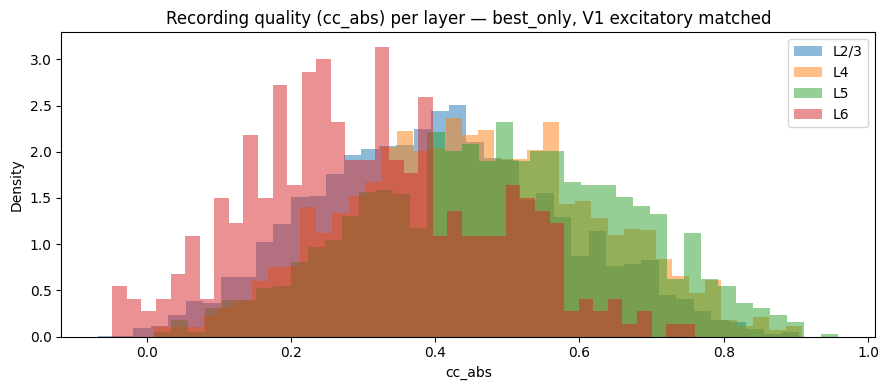

In [5]:
# ── cc_abs quality distribution per layer ─────────────────────────────────────
if 'cc_abs' in matched.columns:
    print('── cc_abs summary per layer ──')
    print(matched.groupby('layer')['cc_abs'].describe().round(3).to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    for layer, grp in matched.groupby('layer'):
        if layer not in ('L1',):
            ax.hist(grp['cc_abs'].dropna(), bins=40, alpha=0.5, label=layer, density=True)
    ax.set_xlabel('cc_abs')
    ax.set_ylabel('Density')
    ax.set_title('Recording quality (cc_abs) per layer — best_only, V1 excitatory matched')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('cc_abs column not found — skipping quality plot.')

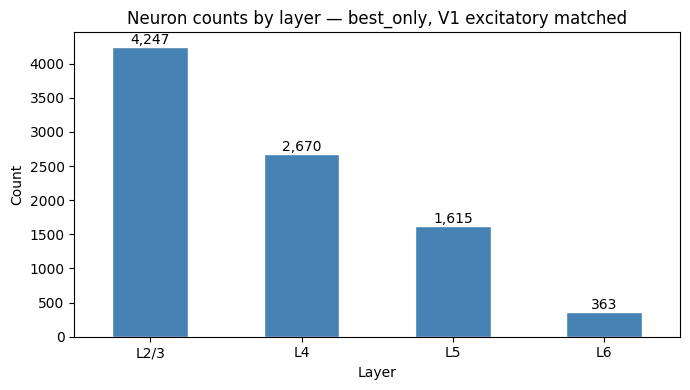

In [6]:
# ── Class counts bar chart ────────────────────────────────────────────────────
layer_counts = matched['layer'].value_counts().sort_index()
layer_counts = layer_counts[layer_counts.index != 'L1']  # drop L1 (non-excitatory)

fig, ax = plt.subplots(figsize=(7, 4))
layer_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Neuron counts by layer — best_only, V1 excitatory matched')
ax.set_xlabel('Layer')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Load functional H5 file

In [7]:
from reader import MicronsReader

H5_CANDIDATES = [
    ROOT / 'microns.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
]
functional_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if functional_path is None:
    raise FileNotFoundError(f'No functional H5 found. Tried: {H5_CANDIDATES}')

print(f'Functional file: {functional_path}')
funcreader   = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = (
    pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Session/scan keys available: {len(scan_df)}')
print(scan_df.to_string())

Functional file: c:\Users\tomma\Desktop\NEUROSCIENCE\microns.h5
Session/scan keys available: 14
    session  scan_idx  key
0         4         7  4_7
1         5         6  5_6
2         5         7  5_7
3         6         2  6_2
4         6         4  6_4
5         6         6  6_6
6         6         7  6_7
7         7         3  7_3
8         7         4  7_4
9         7         5  7_5
10        8         5  8_5
11        9         3  9_3
12        9         4  9_4
13        9         6  9_6


## 5. Helper functions

In [8]:
def zscore_1d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x)
    return (x - m) / (s + eps)


def resample_to(arr: np.ndarray, target_len: int) -> np.ndarray:
    """Linearly resample a 1-D array to exactly target_len points."""
    arr = np.asarray(arr, dtype=np.float32).ravel()
    if arr.size == target_len:
        return arr
    old_idx = np.linspace(0, 1, arr.size)
    new_idx = np.linspace(0, 1, target_len)
    return np.interp(new_idx, old_idx, arr).astype(np.float32)


def extract_stim_channels(clip: np.ndarray, target_len: int) -> np.ndarray:
    """
    Extract 7 per-frame stimulus feature time series from a (F, H, W) clip.
    Returns (7, target_len) array, each channel z-scored.
    Channels: mean_intensity, std_intensity, motion_energy, grad_energy,
              edge_fraction, center_surround, norm_contrast.
    """
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        return np.zeros((7, target_len), dtype=np.float32)
    F, H, W = frames.shape
    eps = 1e-8

    pix            = frames.reshape(F, -1)
    mean_intensity = pix.mean(axis=1)
    std_intensity  = pix.std(axis=1)

    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion_energy = np.concatenate([[0.0], d.reshape(F - 1, -1).mean(axis=1)])
    else:
        motion_energy = np.zeros(F, dtype=np.float32)

    grad_energy   = np.zeros(F, dtype=np.float32)
    edge_fraction = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx * gx + gy * gy)
        grad_energy[i]  = gm.mean()
        thr = np.percentile(gm, 85)
        edge_fraction[i] = (gm > thr).mean()

    h0, h1 = H // 4, (3 * H) // 4
    w0, w1 = W // 4, (3 * W) // 4
    center       = frames[:, h0:h1, w0:w1]
    center_mean  = center.reshape(F, -1).mean(axis=1)
    surround_n   = (H * W) - ((h1 - h0) * (w1 - w0))
    surround_mean = (
        pix.sum(axis=1) - center.reshape(F, -1).sum(axis=1)
    ) / max(surround_n, 1)
    center_surround = center_mean - surround_mean
    norm_contrast   = std_intensity / (mean_intensity + eps)

    raw = [mean_intensity, std_intensity, motion_energy,
           grad_energy, edge_fraction, center_surround, norm_contrast]
    result = np.zeros((7, target_len), dtype=np.float32)
    for i, ch in enumerate(raw):
        result[i] = zscore_1d(resample_to(ch, target_len))
    return result


def extract_behaviour_channels(trial: dict, target_len: int) -> np.ndarray:
    """
    Extract treadmill + pupil channels from a trial dict.
    Returns (4, target_len): [treadmill, pupil_x, pupil_y, pupil_size].
    """
    result = np.zeros((4, target_len), dtype=np.float32)

    treadmill = np.asarray(trial['treadmill'], dtype=np.float32).ravel()
    treadmill = np.where(np.isfinite(treadmill), treadmill, 0.0)
    result[0] = zscore_1d(resample_to(treadmill, target_len))

    pupil = np.asarray(trial['pupil'], dtype=np.float32)
    if pupil.ndim == 2:
        if pupil.shape[1] == 3 and pupil.shape[0] != 3:
            pupil = pupil.T
        if pupil.shape[0] >= 3:
            for i in range(3):
                ch = np.where(np.isfinite(pupil[i]), pupil[i], 0.0)
                result[1 + i] = zscore_1d(resample_to(ch, target_len))
    elif pupil.ndim == 1 and pupil.size > 0:
        ch = np.where(np.isfinite(pupil), pupil, 0.0)
        result[3] = zscore_1d(resample_to(ch, target_len))

    return result


print('Helper functions defined.')

Helper functions defined.


## 6. Build multi-channel dataset

**One sample per neuron** (`nucleus_id` / `target_id`).  
The first trial encountered for a given neuron is used — subsequent trials for the same neuron are skipped.  
This preserves the best-only guarantee at the sample level.

In [9]:
# ── Constants ──────────────────────────────────────────────────────────────────
MAX_TRIALS_PER_SCAN = 8    # trials per session/scan to process (runtime budget)
MIN_TRACE_LEN       = 60   # frames; traces shorter than this are skipped
TARGET_LEN          = 300  # all channels resampled to this length
EXCLUDE_LAYERS      = {'L1'}

N_CHANNELS = 12  # 1 neural + 7 stimulus + 4 behaviour

STIM_CHANNEL_NAMES = [
    'stim_mean', 'stim_std', 'stim_motion',
    'stim_grad', 'stim_edge_frac', 'stim_center_surround', 'stim_norm_contrast',
]
BEH_CHANNEL_NAMES  = ['treadmill', 'pupil_x', 'pupil_y', 'pupil_size']
CHANNEL_NAMES      = ['neural_response'] + STIM_CHANNEL_NAMES + BEH_CHANNEL_NAMES

print(f'Channels ({N_CHANNELS}): {CHANNEL_NAMES}')
print(f'Target sequence length: {TARGET_LEN}')

Channels (12): ['neural_response', 'stim_mean', 'stim_std', 'stim_motion', 'stim_grad', 'stim_edge_frac', 'stim_center_surround', 'stim_norm_contrast', 'treadmill', 'pupil_x', 'pupil_y', 'pupil_size']
Target sequence length: 300


In [10]:
# ── Data collection — one sample per nucleus_id ───────────────────────────────
print(f'Neuron identity column: {neuron_key_col}')

neuron_records = {}   # neuron_key -> record dict
clip_cache     = {}   # cond_hash  -> stim_channels (7, TARGET_LEN) | None

matched_scans = (
    matched[['session', 'scan_idx']]
    .dropna()
    .drop_duplicates()
    .copy()
)
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = (
    scan_df
    .merge(matched_scans, on=['session', 'scan_idx'], how='inner')
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Candidate session/scan pairs: {len(scan_candidates)}')

for _, srow in scan_candidates.iterrows():
    session  = int(srow['session'])
    scan_idx = int(srow['scan_idx'])
    key      = srow['key']

    sess_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy()
    sess_neurons = sess_neurons.dropna(subset=[unit_id_col, 'layer', neuron_key_col])
    sess_neurons['layer'] = sess_neurons['layer'].astype(str)
    sess_neurons = sess_neurons[~sess_neurons['layer'].isin(EXCLUDE_LAYERS)]
    if sess_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}
    n_trials       = min(len(hashes), MAX_TRIALS_PER_SCAN)

    for t in range(n_trials):
        try:
            td = funcreader.get_trial(key, t)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue

        cond_hash = hashes[t]
        if cond_hash not in clip_cache:
            clip, _ = funcreader.get_video_data(cond_hash)
            clip_cache[cond_hash] = (
                extract_stim_channels(clip, TARGET_LEN) if clip is not None else None
            )

        stim_ch = clip_cache[cond_hash]   # (7, T) or None
        beh_ch  = extract_behaviour_channels(td, TARGET_LEN)  # (4, T)
        responses = td['responses']

        for _, nr in sess_neurons.iterrows():
            nkey = int(nr[neuron_key_col])
            if nkey in neuron_records:  # one sample per neuron — skip duplicates
                continue

            fuid    = int(nr[unit_id_col])
            row_idx = unit_id_to_row.get(fuid)
            if row_idx is None or row_idx >= responses.shape[0]:
                continue

            trace = np.asarray(responses[row_idx, :], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue

            trace    = zscore_1d(resample_to(trace, TARGET_LEN))
            multichan = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float32)
            multichan[0]    = trace
            if stim_ch is not None:
                multichan[1:8] = stim_ch
            multichan[8:12] = beh_ch

            neuron_records[nkey] = {
                'neuron_key': nkey,
                'layer':      str(nr['layer']),
                'multichan':  multichan,
                'unit_id':    fuid,
                'session':    session,
                'scan_idx':   scan_idx,
                'trial_idx':  t,
            }

records = list(neuron_records.values())
print(f'\nTotal unique neuron samples collected: {len(records):,}')
print('Samples by layer:')
print(pd.Series([r['layer'] for r in records]).value_counts().sort_index().to_string())

Neuron identity column: unit_id
Candidate session/scan pairs: 13

Total unique neuron samples collected: 5,267
Samples by layer:
L2/3    2237
L4      1611
L5      1126
L6       293


## 7. Train / test split

Split by **neuron identity** (not by trial) to prevent data leakage.  
Rare classes with fewer than 20 neurons are dropped before splitting.

In [11]:
neuron_df = pd.DataFrame([
    {'neuron_key': r['neuron_key'], 'layer': r['layer']} for r in records
]).drop_duplicates(subset=['neuron_key'])

layer_counts = neuron_df['layer'].value_counts()
keep_layers  = layer_counts[layer_counts >= 20].index.tolist()
neuron_df    = neuron_df[neuron_df['layer'].isin(keep_layers)].copy()

print('Neurons per layer (after rare-class filter):')
print(neuron_df['layer'].value_counts().sort_index().to_string())

# 75/25 stratified split on layer
train_neurons, test_neurons = train_test_split(
    neuron_df['neuron_key'].values,
    test_size=0.25,
    random_state=42,
    stratify=neuron_df['layer'].values,
)
train_set = set(train_neurons)
test_set  = set(test_neurons)
print(f'\nTrain neurons: {len(train_set):,} | Test neurons: {len(test_set):,}')

enc = LabelEncoder()
enc.fit(neuron_df['layer'])
print(f'Classes: {list(enc.classes_)}')


def build_split(neuron_keys_set):
    X, y, uids = [], [], []
    for r in records:
        if r['neuron_key'] not in neuron_keys_set or r['layer'] not in keep_layers:
            continue
        X.append(r['multichan'])
        y.append(r['layer'])
        uids.append(r['neuron_key'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)


X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)

print(f'\nTrain shape: {X_train.shape}  |  Test shape: {X_test.shape}')
print(f'(samples, channels={X_train.shape[1]}, time={X_train.shape[2]})')
print('\nTrain class distribution:')
print(pd.Series(enc.inverse_transform(y_train)).value_counts().sort_index().to_string())
print('\nTest class distribution:')
print(pd.Series(enc.inverse_transform(y_test)).value_counts().sort_index().to_string())

Neurons per layer (after rare-class filter):
layer
L2/3    2237
L4      1611
L5      1126
L6       293

Train neurons: 3,950 | Test neurons: 1,317
Classes: ['L2/3', 'L4', 'L5', 'L6']

Train shape: (3950, 12, 300)  |  Test shape: (1317, 12, 300)
(samples, channels=12, time=300)

Train class distribution:
L2/3    1678
L4      1208
L5       844
L6       220

Test class distribution:
L2/3    559
L4      403
L5      282
L6       73


## 8. PyTorch setup

In [12]:
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
    ])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

n_classes    = len(enc.classes_)
class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()
print(f'Class weights: {dict(zip(enc.classes_, class_weights.cpu().numpy().round(4)))}')

BATCH_SIZE = 128


def make_loader(X, y, shuffle):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE,
                      shuffle=shuffle, drop_last=False)


train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

PyTorch 2.11.0+cpu | device: cpu
Class weights: {'L2/3': np.float32(0.0833), 'L4': np.float32(0.1157), 'L5': np.float32(0.1656), 'L6': np.float32(0.6354)}
Train batches: 31 | Test batches: 11


## 9. CNN architectures

Three architectures from `CNN_multichannel.ipynb`:

| Model | Description |
|-------|-------------|
| **ShallowCNN** | 3 Conv blocks → MLP head |
| **ResidualCNN** | Residual blocks with adaptive pooling |
| **MultiStreamCNN** | Parallel first-layer branches for neural+behaviour, neural+stimulus, all channels |

In [13]:
# ── ShallowCNN ────────────────────────────────────────────────────────────────
class MultiChannelShallowCNN(nn.Module):
    def __init__(self, in_channels: int, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=7, padding=3), nn.BatchNorm1d(64),  nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(64,         128,  kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,        256,  kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        flat = 256 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.head(self.conv(x))


# ── ResidualCNN ───────────────────────────────────────────────────────────────
class ResBlock1d(nn.Module):
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels), nn.ReLU(True),
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.ReLU(True)

    def forward(self, x):
        return self.act(self.net(x) + x)


class MultiChannelResidualCNN(nn.Module):
    def __init__(self, in_channels: int, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
        )
        self.stage1 = nn.Sequential(
            ResBlock1d(64),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(True),
        )
        self.stage2 = nn.Sequential(
            ResBlock1d(128),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(256), nn.ReLU(True),
        )
        self.stage3 = nn.Sequential(ResBlock1d(256))
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.head   = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.head(self.pool(x))


# ── MultiStreamCNN ────────────────────────────────────────────────────────────
class MultiStreamCNN(nn.Module):
    NB_IDX  = [0, 8, 9, 10, 11]   # neural + behaviour
    NS_IDX  = list(range(8))       # neural + stimulus
    ALL_IDX = list(range(12))      # all channels

    def __init__(self, n_channels: int, seq_len: int, n_classes: int,
                 k_nb: int = 48, k_ns: int = 48, k_all: int = 32,
                 dropout: float = 0.4):
        super().__init__()

        def _branch(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=7, padding=3, bias=False),
                nn.BatchNorm1d(out_ch), nn.ReLU(True), nn.MaxPool1d(2),
            )

        self.branch_nb  = _branch(len(self.NB_IDX),  k_nb)
        self.branch_ns  = _branch(len(self.NS_IDX),  k_ns)
        self.branch_all = _branch(len(self.ALL_IDX), k_all)

        fused = k_nb + k_ns + k_all  # 128
        self.backbone = nn.Sequential(
            nn.Conv1d(fused, 128, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,   256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        flat = 256 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        nb   = self.branch_nb (x[:, self.NB_IDX,  :])
        ns   = self.branch_ns (x[:, self.NS_IDX,  :])
        all_ = self.branch_all(x[:, self.ALL_IDX, :])
        return self.head(self.backbone(torch.cat([nb, ns, all_], dim=1)))


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

shallow_cnn  = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
residual_cnn = MultiChannelResidualCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
multi_stream = MultiStreamCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)

print(f'ShallowCNN  params: {count_params(shallow_cnn):,}')
print(f'ResidualCNN params: {count_params(residual_cnn):,}')
print(f'MultiStream params: {count_params(multi_stream):,}')

ShallowCNN  params: 2,572,100
ResidualCNN params: 680,452
MultiStream params: 2,614,420


## 10. Training utilities

In [14]:
def train_model(model, train_loader, test_loader, *,
                lr=3e-4, weight_decay=1e-4,
                max_epochs=150, patience=25,
                label='model'):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max_epochs)

    history       = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits   = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'[{label}] Early stop at epoch {epoch}')
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d} | '
                  f'train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}')

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'[{label}] Best checkpoint restored (val_loss={best_val_loss:.4f})')
    return history


def evaluate(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


print('Training utilities defined.')

Training utilities defined.


## 11. Train — ShallowCNN

In [15]:
shallow_cnn     = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
history_shallow = train_model(shallow_cnn, train_loader, test_loader, label='ShallowCNN')

[ShallowCNN] Epoch   1 | train=1.2689  val=1.1067  acc=0.369
[ShallowCNN] Epoch   5 | train=1.0830  val=1.0625  acc=0.405
[ShallowCNN] Epoch  10 | train=0.9632  val=1.0833  acc=0.492
[ShallowCNN] Epoch  15 | train=0.7504  val=0.9613  acc=0.530
[ShallowCNN] Epoch  20 | train=0.4816  val=0.8411  acc=0.667
[ShallowCNN] Epoch  25 | train=0.3330  val=0.8410  acc=0.711
[ShallowCNN] Epoch  30 | train=0.2424  val=0.7877  acc=0.765
[ShallowCNN] Epoch  35 | train=0.1935  val=0.8176  acc=0.762
[ShallowCNN] Epoch  40 | train=0.1503  val=0.8930  acc=0.774
[ShallowCNN] Epoch  45 | train=0.1404  val=0.8408  acc=0.792
[ShallowCNN] Early stop at epoch 48
[ShallowCNN] Best checkpoint restored (val_loss=0.7547)


## 13. Train — MultiStreamCNN

In [16]:
multi_stream    = MultiStreamCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
history_ms      = train_model(multi_stream, train_loader, test_loader, label='MultiStreamCNN')

[MultiStreamCNN] Epoch   1 | train=1.3117  val=1.1117  acc=0.339
[MultiStreamCNN] Epoch   5 | train=1.0525  val=1.0838  acc=0.383
[MultiStreamCNN] Epoch  10 | train=0.8742  val=1.0098  acc=0.512
[MultiStreamCNN] Epoch  15 | train=0.5093  val=0.6984  acc=0.700
[MultiStreamCNN] Epoch  20 | train=0.3045  val=0.6787  acc=0.776
[MultiStreamCNN] Epoch  25 | train=0.2292  val=0.5925  acc=0.809
[MultiStreamCNN] Epoch  30 | train=0.1739  val=0.6084  acc=0.813
[MultiStreamCNN] Epoch  35 | train=0.1464  val=0.7110  acc=0.830
[MultiStreamCNN] Epoch  40 | train=0.1288  val=0.7463  acc=0.815
[MultiStreamCNN] Early stop at epoch 44
[MultiStreamCNN] Best checkpoint restored (val_loss=0.5762)


## 14. Training curves

In [17]:
histories = [
    (history_shallow, 'ShallowCNN'),
    (history_res,     'ResidualCNN'),
    (history_ms,      'MultiStreamCNN'),
]

fig, axes = plt.subplots(len(histories), 2, figsize=(14, 4 * len(histories)))
for row, (hist, name) in enumerate(histories):
    ax_loss, ax_acc = axes[row]
    ax_loss.plot(hist['train_loss'], label='train')
    ax_loss.plot(hist['val_loss'],   label='val')
    ax_loss.set_title(f'{name} — loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Cross-entropy')
    ax_loss.legend()

    ax_acc.plot(hist['val_acc'], color='steelblue')
    ax_acc.axhline(1 / n_classes, color='grey', linestyle='--',
                   label=f'chance ({1/n_classes:.2f})')
    ax_acc.set_title(f'{name} — val accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

plt.tight_layout()
plt.show()

NameError: name 'history_res' is not defined

## 15. Evaluation — trial-level metrics

In [ ]:
eval_results = []
model_pairs  = [
    (shallow_cnn,  'ShallowCNN'),
    (residual_cnn, 'ResidualCNN'),
    (multi_stream, 'MultiStreamCNN'),
]

for model, name in model_pairs:
    y_pred = evaluate(model, test_loader)
    eval_results.append({
        'model':             name,
        'accuracy':          accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'macro_f1':          f1_score(y_test, y_pred, average='macro'),
    })
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=enc.classes_))

comparison_df = (
    pd.DataFrame(eval_results)
    .sort_values('balanced_accuracy', ascending=False)
    .reset_index(drop=True)
)
print('\n── Model comparison ──')
display(comparison_df.round(4))

## 16. Confusion matrices

In [ ]:
fig, axes = plt.subplots(1, len(model_pairs), figsize=(7 * len(model_pairs), 5))

for ax, (model, name) in zip(axes, model_pairs):
    y_pred = evaluate(model, test_loader)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=enc.classes_,
        xticks_rotation=45,
        cmap='Blues',
        normalize='true',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f'{name}\n(normalised by true class)')

plt.tight_layout()
plt.show()

## 17. Per-neuron majority-vote

Since each neuron contributes exactly one sample (best-only regime), majority vote is
identical to trial-level accuracy here.  
The cell is included for completeness and to match the `CNN_multichannel.ipynb` structure.

In [ ]:
from scipy.stats import mode as scipy_mode


def per_neuron_majority_vote(model, X, y, uids):
    loader = make_loader(X, y, shuffle=False)
    preds  = evaluate(model, loader)

    neuron_preds = {}
    neuron_true  = {}
    for uid, pred, true in zip(uids, preds, y):
        neuron_preds.setdefault(uid, []).append(pred)
        neuron_true[uid] = true

    voted_preds, voted_true = [], []
    for uid in neuron_preds:
        majority = scipy_mode(neuron_preds[uid], keepdims=False).mode
        voted_preds.append(majority)
        voted_true.append(neuron_true[uid])

    return np.array(voted_true), np.array(voted_preds)


print('Per-neuron majority-vote results (best-only: one sample = one neuron):')
for model, name in model_pairs:
    vt, vp = per_neuron_majority_vote(model, X_test, y_test, uids_test)
    print(f'\n{name}  ({len(vt)} neurons)')
    print(f'  Accuracy          : {accuracy_score(vt, vp):.3f}')
    print(f'  Balanced accuracy : {balanced_accuracy_score(vt, vp):.3f}')
    print(f'  Macro F1          : {f1_score(vt, vp, average="macro"):.3f}')

## 18. First-layer filter visualisation (MultiStreamCNN)

In [ ]:
branch_specs = [
    ('branch_nb  (neural + behaviour)',
     multi_stream.branch_nb,
     [CHANNEL_NAMES[i] for i in MultiStreamCNN.NB_IDX]),
    ('branch_ns  (neural + stimulus)',
     multi_stream.branch_ns,
     [CHANNEL_NAMES[i] for i in MultiStreamCNN.NS_IDX]),
    ('branch_all (all channels)',
     multi_stream.branch_all,
     CHANNEL_NAMES),
]

N_SHOW = 16
for branch_label, branch, ch_labels in branch_specs:
    filters = branch[0].weight.detach().cpu().numpy()  # (out_ch, in_ch, kernel)
    n_show  = min(N_SHOW, filters.shape[0])
    n_in    = len(ch_labels)

    fig, axes = plt.subplots(n_in, n_show, figsize=(n_show * 1.1, n_in * 0.9))
    if n_in == 1:
        axes = axes[np.newaxis, :]

    for ch in range(n_in):
        for f in range(n_show):
            ax = axes[ch, f]
            ax.plot(filters[f, ch], linewidth=1)
            ax.axhline(0, color='grey', linewidth=0.4)
            ax.set_xticks([])
            ax.set_yticks([])
            if f == 0:
                ax.set_ylabel(ch_labels[ch], fontsize=6, rotation=0,
                              ha='right', va='center', labelpad=60)
            if ch == 0:
                ax.set_title(f'F{f}', fontsize=7)

    fig.suptitle(f'MultiStreamCNN — {branch_label}', y=1.01)
    plt.tight_layout()
    plt.show()

## Summary

| Step | Result |
|------|--------|
| Filter: best_only + V1 + excitatory + matched | ~8.9k neurons (WORKFLOW.md §2.1) |
| Input tensor | (N, 12, 300) — 1 neural + 7 stimulus + 4 behaviour channels |
| Split | 75% train / 25% test, stratified by layer, split by `nucleus_id` |
| Primary metric | Balanced accuracy (accounts for class imbalance L2/3 >> L6) |

### Key differences from `CNN_multichannel.ipynb`

- `functional_data='best_only'` instead of `'match'`: fewer neurons (~8.9k vs ~13k) but **no repeated-measure dependence** — every `nucleus_id` appears exactly once.
- Since best-only guarantees one sample per neuron, per-neuron majority vote is identical to trial-level accuracy (no averaging needed).
- This dataset is the **primary regime** for all downstream modeling (WORKFLOW.md §3.1).

### Limitations (inherited from CNN_multichannel.ipynb)

- Stimulus channels are linearly resampled to match the neural frame rate — sub-frame temporal structure is lost.
- Only `MAX_TRIALS_PER_SCAN = 8` trials per session are used to keep runtime manageable.
- Validation split is by neuron, not by scan session. A leave-one-session-out split would be a stricter confound check (WORKFLOW.md §6.1bis).